In [1]:
%matplotlib inline

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("plant_data_7params_3000.csv")

X = data[['moisture','temperature','humidity','light','ph','air_quality','nutrient']]
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost Model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

# Manual prediction
new_data = pd.DataFrame(
    [[200, 30, 50, 500, 6.5, 400, 60]],
    columns=['moisture','temperature','humidity','light','ph','air_quality','nutrient']
)
prediction = model.predict(new_data)
print("Plant condition:", prediction[0])

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['healthy' 'stress' 'water_needed']

c:\Users\pawan\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:05:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy (XGBoost): 1.0


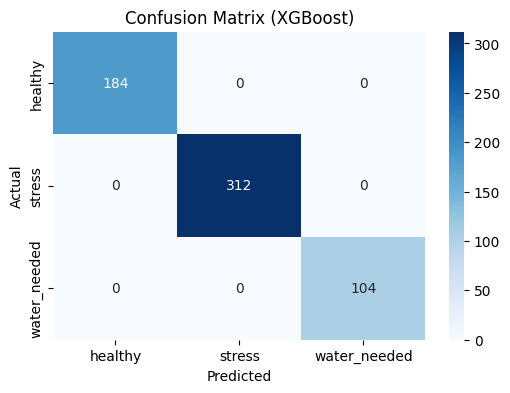

Plant condition: healthy


In [2]:
%matplotlib inline

import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder  # <-- Yeh zaroori hai
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
data = pd.read_csv("plant_data_7params_3000.csv")

X = data[['moisture','temperature','humidity','light','ph','air_quality','nutrient']]
y = data['label']

# 2. Label Encoding (Fix for the ValueError)
# XGBoost ko text ki jagah 0, 1, 2 chahiye hota hai
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Data Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 4. XGBoost Model
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
model.fit(X_train, y_train)

# 5. Predictions & Accuracy
y_pred = model.predict(X_test)
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred))

# 6. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
# le.classes_ use karenge taaki axis par original names (healthy, etc.) aayein
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

# 7. Manual prediction
new_data = pd.DataFrame(
    [[200, 30, 50, 500, 6.5, 400, 60]],
    columns=['moisture','temperature','humidity','light','ph','air_quality','nutrient']
)

# Predict number (0, 1, or 2)
prediction_numeric = model.predict(new_data)

# Convert number back to text (Example: 0 -> 'healthy')
prediction_text = le.inverse_transform(prediction_numeric)

print("Plant condition:", prediction_text[0])